In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar

In [3]:
# CONSTANTS
n = 40
L = 1/10
m = 1/10
k = 70
g = 9.81

In [4]:
def total_potential_gravity(x_s,y_s):
    global g,k,m
    n = len(x_s)
    first_part = 1/2* k * sum([pow(np.sqrt( (x_s[i] - x_s[i+1])**2  + (y_s[i] - y_s[i+1])**2)-L,2) for i in range(n-1)])
    second_part = g *m* sum(y_s)

    return first_part + second_part

In [5]:
def generate_points(x0,y0,xk,yk,n):
    x_s = np.arange(x0,xk,(xk-x0)/n)
    y_s = np.arange(y0,yk,(yk-y0)/n)
    return x_s, y_s

In [6]:
x_0 = 0
y_0 = 0
x_k = 3
y_k = 1
x_s, y_s = generate_points(x_0,y_0,x_k,y_k,n)
print(x_s)
print(y_s)

[0.    0.075 0.15  0.225 0.3   0.375 0.45  0.525 0.6   0.675 0.75  0.825
 0.9   0.975 1.05  1.125 1.2   1.275 1.35  1.425 1.5   1.575 1.65  1.725
 1.8   1.875 1.95  2.025 2.1   2.175 2.25  2.325 2.4   2.475 2.55  2.625
 2.7   2.775 2.85  2.925]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975]


In [7]:
print(total_potential_gravity(x_s,y_s))

19.728204969350813


In [8]:
def gradient(x_s,y_s):
    n = len(x_s)
    global k,g,m

    x_grad = [
        k*(2*x_s[i] - x_s[i-1] - x_s[i+1] - L*(x_s[i]-x_s[i+1])/np.sqrt((x_s[i]-x_s[i+1])**2 + (y_s[i]-y_s[i+1])**2)  +L*(x_s[i-1]-x_s[i])/np.sqrt((x_s[i-1]-x_s[i])**2 + (y_s[i-1]-y_s[i])**2))
        for i in range(1,n-1)]


    y_grad = [
        k*(2*y_s[i] - y_s[i-1] - y_s[i+1] - L*(y_s[i]-y_s[i+1])/np.sqrt((x_s[i]-x_s[i+1])**2 + (y_s[i]-y_s[i+1])**2)  +L*(y_s[i-1]-y_s[i])/np.sqrt((x_s[i-1]-x_s[i])**2 + (y_s[i-1]-y_s[i])**2)) + g*m
        for i in range(1,n-1)]

    return np.array([0]+x_grad+[0]),np.array([0]+y_grad+[0])

In [9]:
x_grad,y_grad = gradient(x_s,y_s)
print(x_grad)
print(y_grad)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.94289029e-15
  0.00000000e+00  9.71445147e-16 -4.85722573e-15  5.82867088e-15
  0.00000000e+00 -5.82867088e-15  4.85722573e-15  0.00000000e+00
 -4.85722573e-15 -1.94289029e-15  1.94289029e-15 -2.91433544e-15
  0.00000000e+00  2.91433544e-15 -1.65145675e-14  1.65145675e-14
 -2.91433544e-15  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -9.71445147e-15  9.71445147e-15  0.00000000e+00 -2.91433544e-14
  2.81719092e-14 -2.42861287e-14  2.42861287e-14 -2.81719092e-14
  0.00000000e+00  2.81719092e-14 -2.42861287e-14  2.42861287e-14
 -2.81719092e-14  0.00000000e+00  2.81719092e-14  0.00000000e+00]
[0.    0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981
 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981
 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981 0.981
 0.981 0.981 0.981 0.   ]


In [39]:
def gradient_descend(x_s0,y_s0,alpha):
    x_s = np.array(x_s0[:])
    y_s = np.array(y_s0[:])

    i = 0
    eps = 1e-4
    diff = 1
    prev_energy = total_potential_gravity(x_s, y_s)
    while diff>eps and i < 10000:
        x_grad,y_grad = gradient(x_s, y_s)

        y_s -= alpha*y_grad

        new_energy = total_potential_gravity(x_s, y_s)
        diff = abs(new_energy-prev_energy)
        prev_energy = new_energy
        i+=1
    print(i)
    return x_s,y_s

In [40]:
def print_plot(axes,indeks,x_s,y_s,alpha):




    axes[indeks].set_title(f"Optymalna pozycja łańcucha dla stałej {alpha}")
    axes[indeks].axis('equal')
    axes[indeks].scatter(x_s,y_s)


In [41]:
opt_x, opt_y = gradient_descend(x_s,y_s,0.005)

print(opt_x)
print(opt_y)


print(total_potential_gravity(x_s,y_s))
print(total_potential_gravity(opt_x,opt_y))

1970
[0.    0.075 0.15  0.225 0.3   0.375 0.45  0.525 0.6   0.675 0.75  0.825
 0.9   0.975 1.05  1.125 1.2   1.275 1.35  1.425 1.5   1.575 1.65  1.725
 1.8   1.875 1.95  2.025 2.1   2.175 2.25  2.325 2.4   2.475 2.55  2.625
 2.7   2.775 2.85  2.925]
[ 0.         -0.34055112 -0.66692302 -0.97912431 -1.27715844 -1.5610223
 -1.83070451 -2.08618316 -2.32742282 -2.55437047 -2.76694986 -2.96505332
 -3.14852949 -3.31716413 -3.47064838 -3.60852203 -3.7300616  -3.83402111
 -3.91783939 -3.84289683 -3.74601366 -3.63086241 -3.49903451 -3.35141146
 -3.18854088 -3.01078621 -2.81839856 -2.61155576 -2.39038531 -2.1549787
 -1.90540091 -1.64169681 -1.36389574 -1.07201484 -0.76606156 -0.44603551
 -0.11193005  0.23626659  0.59857025  0.975     ]
19.728204969350813
-47.44092949204925


1970
3631
10000


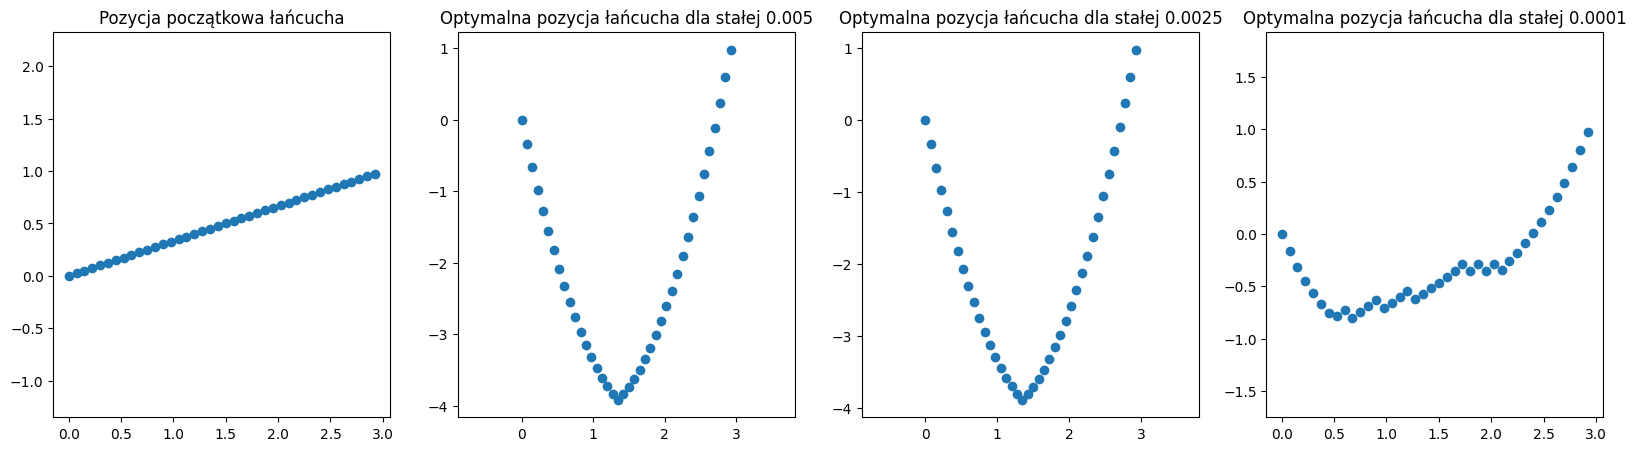

In [42]:
fig,ax = plt.subplots(1,4,figsize=(20, 5))

ax[0].set_title(f"Pozycja początkowa łańcucha")
ax[0].axis('equal')
ax[0].scatter(x_s,y_s)
alphas = [0.005,0.0025,0.0001]
for i,alpha in enumerate(alphas):
    opt_x, opt_y = gradient_descend(x_s,y_s,alpha)
    print_plot(ax,i+1,opt_x,opt_y,alpha)

In [43]:
def gradient_descend_squizzing_alpha(x_s0,y_s0,alpha):
    new_alpha = alpha
    x_s = np.array(x_s0[:])
    y_s = np.array(y_s0[:])

    i = 0
    eps = 1e-4
    diff = 1
    prev_energy = total_potential_gravity(x_s, y_s)
    while diff>eps and i < 10000:
        x_grad,y_grad = gradient(x_s, y_s)

        #x_s -= alpha*x_grad
        y_s -= new_alpha*y_grad

        new_energy = total_potential_gravity(x_s, y_s)
        diff = abs(new_energy-prev_energy)
        prev_energy = new_energy
        i+=1
        new_alpha *= 0.9999
    print(i)
    return x_s,y_s

2134
4214
10000


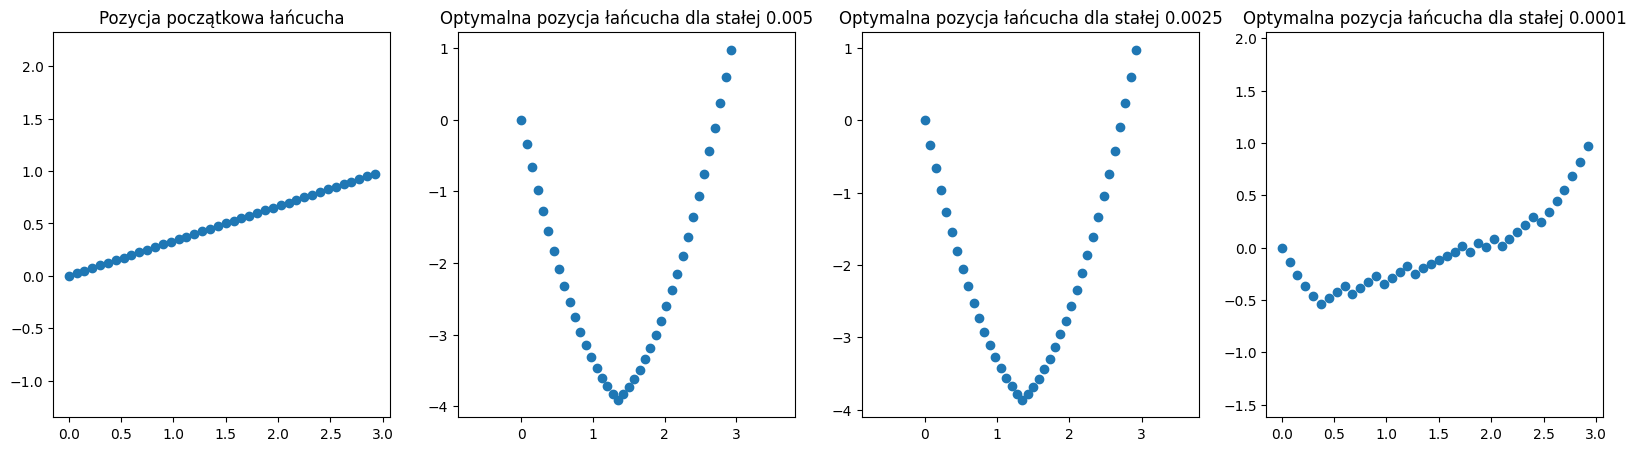

In [44]:
fig,ax = plt.subplots(1,4,figsize=(20, 5))

ax[0].set_title(f"Pozycja początkowa łańcucha")
ax[0].axis('equal')
ax[0].scatter(x_s,y_s)
alphas = [0.005,0.0025,0.0001]
for i,alpha in enumerate(alphas):
    opt_x, opt_y = gradient_descend_squizzing_alpha(x_s,y_s,alpha)
    print_plot(ax,i+1,opt_x,opt_y,alpha)

In [45]:
def line_search(x_s0,y_s0):
    x_s = np.array(x_s0[:])
    y_s = np.array(y_s0[:])

    def check_energy(alp):
        nonlocal x_s,y_s,y_grad
        test_y = y_s - alp*y_grad
        return total_potential_gravity(x_s,test_y)


    i = 0
    eps = 1e-4
    diff = 1
    prev_energy = total_potential_gravity(x_s, y_s)
    while diff>eps and i < 10000:
        x_grad,y_grad = gradient(x_s, y_s)


        new_alpha = minimize_scalar(check_energy,bounds = (0,1)).get('x')
        y_s -= new_alpha*y_grad

        new_energy = total_potential_gravity(x_s, y_s)
        diff = abs(new_energy-prev_energy)
        prev_energy = new_energy
        i+=1
    print(i)
    return x_s,y_s

1298


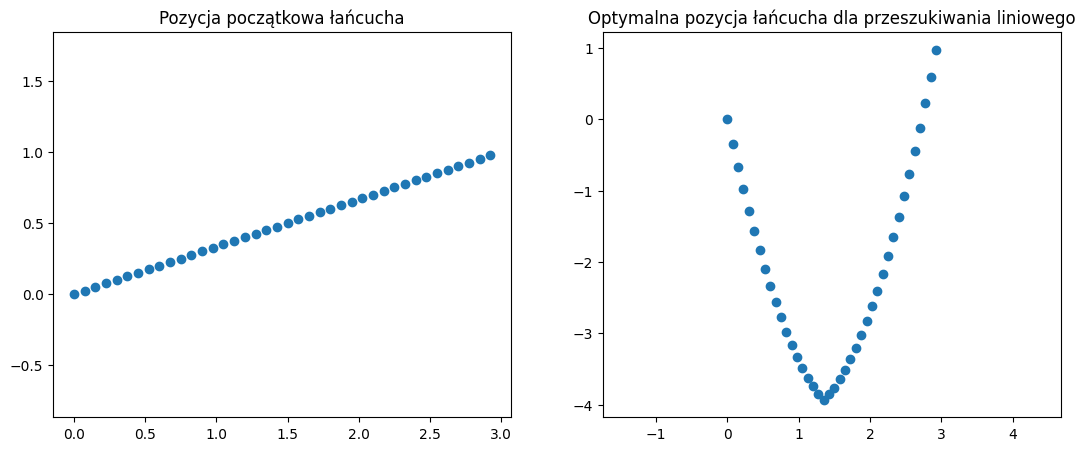

In [46]:
fig,ax = plt.subplots(1,2,figsize=(13, 5))

ax[0].set_title(f"Pozycja początkowa łańcucha")
ax[0].axis('equal')
ax[0].scatter(x_s,y_s)
alphas = [0.005,0.0025,0.0001]

opt_x, opt_y = line_search(x_s,y_s)
ax[1].set_title(f"Optymalna pozycja łańcucha dla przeszukiwania liniowego")
ax[1].axis('equal')
ax[1].scatter(opt_x,opt_y)